## Recency Frequency Monetary (RFM) Analysis using KMeans Clustering from the year 2020 to 2023
### Introduction: Product Segmentation
RFM (Recency, Frequency, Monetary) analysis is a marketing technique used to determine quantitatively which customers are the best ones by examining how recently a customer has purchased (recency), how often they purchase (frequency), and how much the customer spends (monetary).

In [5]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import plotly.express as px
from datetime import datetime
import seaborn as sns
from sklearn.discriminant_analysis import StandardScaler
import warnings
from scipy import stats
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram
from scipy import stats
from scipy.spatial.distance import cdist
warnings.filterwarnings("ignore")

Input the location of the dataset to run the folder

In [6]:
path = '../Data/Intuilize_MNSU_SampleSales_V1_011524 - Intuilize_SampleSales_V1_011524.csv'

### 1. Exploratory Data Analysis

Read in the data 

In [7]:
df = pd.read_csv(path)
df.head()

,LocationID,LocationName,BranchID,BranchName,InvoiceNumber,ProductGroup,ProductCode,CustomerName,CustomerCode,SalesDate,ExtCost,ExtPrice,SalesQty,UnitCost,UnitPrice,GM%
0,1,Dallas,1,ACME Inc,1320612,Electrical,AAA88,Dickinson-Fay,17314,8/11/2021,"$1,685.15","$2,286.99",10.0,$168.5150,$228.6989,26.32
1,1,Dallas,1,ACME Inc,1320619,Electrical,AAA9A,Grimes-Grimes,17373,8/11/2021,$52.74,$90.15,10.0,$5.2743,$9.0149,41.49
2,1,Dallas,1,ACME Inc,1320621,Electrical,AA459,Goyette-Legros,18145,8/11/2021,$41.31,$59.02,1.0,$41.3138,$59.0197,30.00
3,1,Dallas,1,ACME Inc,1320621,Electrical,AA567,Goyette-Legros,18145,8/11/2021,$8.78,$13.46,1.0,$8.7770,$13.4642,34.81
4,1,Dallas,1,ACME Inc,1320622,Electrical,AA570,Lockman-Prosacco,12908,8/11/2021,$49.97,$64.62,2.0,$24.9847,$32.3090,22.67


Removing the preceding '$' from the data and converting it to float
Converting the date to datetime objects

Creating a RFM table

In [8]:
def cleanCurrency(df, columns):
    for col in columns:
        df[col] = df[col].replace('[\$,]', '', regex=True).astype(float)
    
def cleanDate(df, columns):
    for col in columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    

def createRFMDataFrame(df):
    # Create a new dataframe with the necessary columns
    rfm = df.groupby('ProductCode').agg({'SalesDate': lambda date: (df['SalesDate'].max() - date.max()).days,
                                         'InvoiceNumber': lambda num: len(num),
                                         'ExtPrice': lambda price: price.sum()})

    # Convert the SalesDate to int
    rfm['SalesDate'] = rfm['SalesDate'].astype(int)

    # Rename the columns
    rfm.rename(columns={'SalesDate': 'Recency', 
                        'InvoiceNumber': 'Frequency', 
                        'ExtPrice': 'Monetary'}, inplace=True)

    return rfm

cleanCurrency(df, ['ExtPrice', 'ExtCost', 'UnitCost', 'UnitPrice'])
cleanDate(df, ['SalesDate'])
rfm = createRFMDataFrame(df)
rfm['Recency'] = rfm['Recency'].apply(lambda x: x+1)
rfm.head()

,Recency,Frequency,Monetary
ProductCode,,,
"16,X8Aew6833",82,2,39.30
"SS,22Aew1908",16,2,138.66
""" 27""""154DW7457""",618,3,37013.87
""" 8"""" N80OU8459""",183,1,107.56
""" 8"""" N80OU9161""",68,3,37.28


In [9]:
rfm['ProductCode']= rfm.index

In [10]:
rfm['ProductCode'].value_counts()

ProductCode
 16,X8Aew6833    1
KNHML1AX1.75     1
KNHM18X1.5F      1
KNHM1AX1.5       1
KNHM4X.7F        1
                ..
7467/27S9772     1
74686Z440Z4      1
7497Z300A        1
74A00Z1A004      1
z DE533TI565     1
Name: count, Length: 61022, dtype: int64

Visualize the distribution of RFM values

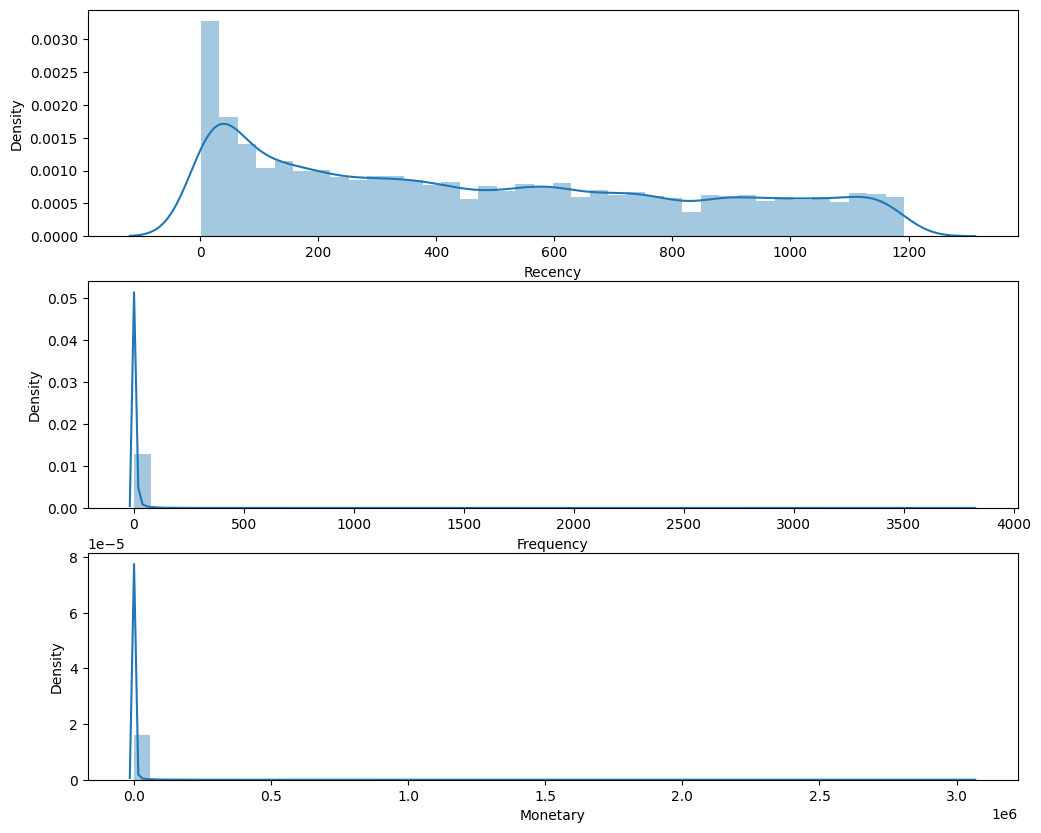

In [11]:
'''
Visualize the distribution of the RFM variables.
'''
def visualizeDistribution(df, columns):
    plt.figure(figsize=(12, 10))
    for i, col in enumerate(columns):
        plt.subplot(3, 1, i+1)
        sns.distplot(df[col])
    plt.show()

visualizeDistribution(rfm, ['Recency', 'Frequency', 'Monetary'])

Visualize and analyze the skewness of the RFM Values

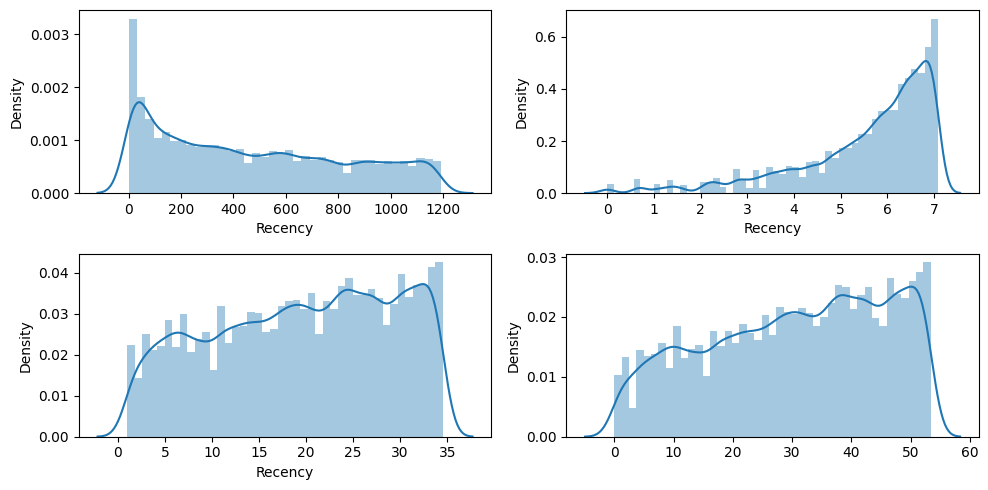

Log Transform: The skew coefficient of 0.39 is reduced to -1.42
Square Root Transform: The skew coefficient of 0.39 is reduced to -0.21
Box Cox Transform: The skew coefficient of 0.39 is reduced to -0.28


In [12]:
def analyze_skewness(x):
    fig, ax = plt.subplots(2, 2, figsize=(10, 5))
    sns.distplot(rfm[x], ax=ax[0,0])
    sns.distplot(np.log(rfm[x]), ax=ax[0,1])  # Change displot to histplot for univariate distributions
    sns.distplot(np.sqrt(rfm[x]), ax=ax[1,0])  # Change displot to histplot for univariate distributions
    sns.distplot(stats.boxcox(rfm[x])[0], ax=ax[1,1])  # Change displot to histplot for univariate distributions
    plt.tight_layout()
    plt.show()

    print('Log Transform: The skew coefficient of', rfm[x].skew().round(2), 'is reduced to', np.log(rfm[x]).skew().round(2))
    print('Square Root Transform: The skew coefficient of', rfm[x].skew().round(2), 'is reduced to', np.sqrt(rfm[x]).skew().round(2))
    print('Box Cox Transform: The skew coefficient of', rfm[x].skew().round(2), 'is reduced to', pd.Series(stats.boxcox(rfm[x])[0]).skew().round(2))
analyze_skewness('Recency')

## 2. Data Preprocessing and Transformation.

Using box cox transformation to reduce the skewness of the RFM values

In [13]:
def fix_skewness(df, columns):
    """
    Fix skewness in specified columns of a DataFrame using Box-Cox transformation.

    Parameters:
    - df: DataFrame: Input DataFrame
    - columns: list of str: List of column names to fix skewness

    Returns:
    - df_fixed: DataFrame: DataFrame with skewness fixed in specified columns
    """
    df_fixed = pd.DataFrame()
    for column in columns:
        df_fixed[column] = stats.boxcox(df[column])[0]
    return df_fixed

# Example usage:
rfm_columns = ['Recency', 'Frequency', 'Monetary']
customers_fix = fix_skewness(rfm, rfm_columns)
customers_fix.tail()

,Recency,Frequency,Monetary
61017,29.614277,0.00000,2.627489
61018,42.404890,0.99306,4.589078
61019,19.052863,0.00000,5.283756
61020,28.299718,0.00000,4.276010
61021,37.872864,0.00000,3.609591


Normalizing the RFM values

In [14]:
'''
Normalize the data and round the mean to two decimal places.
'''
def scaleData(data):
    scaler = StandardScaler()
    scaler.fit(data)
    scaler.transform(data)
    return scaler.transform(data)
customer_normalized = scaleData(customers_fix)
print(customer_normalized.mean(axis = 0).round(2))
print(customer_normalized.std(axis = 0).round(2))

[-0.  0. -0.]
[1. 1. 1.]


Elbow method to find the optimal number of clusters

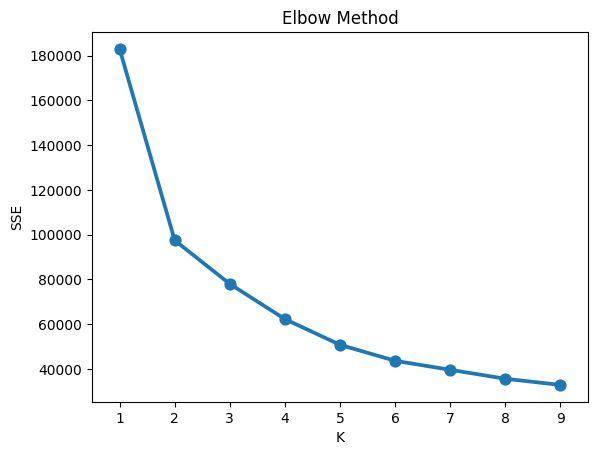

In [15]:
def elbowMethod(data):
    distortions = []
    K = range(1, 10)
    inertias = []
    mapping1 = {}
    sse = {}
    for k in K:
        # Building and fitting the model
        kmeanModel = KMeans(n_clusters=k).fit(data)
        kmeanModel.fit(data)
        distortions.append(sum(np.min(cdist(data, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / data.shape[0])
        inertias.append(kmeanModel.inertia_)
        mapping1[k] = sum(np.min(cdist(data, kmeanModel.cluster_centers_, 'euclidean'), axis=1)) / data.shape[0]
        sse[k] = kmeanModel.inertia_
    plt.title('Elbow Method')
    plt.xlabel('K')
    plt.ylabel('SSE')
    sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
    plt.show()

elbowMethod(customer_normalized)

## 3. Modeling the Data with Kmeans Clustering

Fit the data into KMeans clustering model

In [16]:
'''
Create a KMeans model with the specified number of clusters.
'''
def kmeansModel(data, clusters):
    kmeans = KMeans(n_clusters=clusters, random_state=42)
    kmeans.fit(data)
    return kmeans
model = kmeansModel(customer_normalized, 4)
model.labels_.shape
rfm['Cluster'] = model.labels_
rfm.head()
# Group the data by cluster and aggregate them by their mean
rfm.groupby('Cluster').agg({'Recency': 'mean', 'Frequency': 'mean', 'Monetary': 'mean'}).round(2)

,Recency,Frequency,Monetary
Cluster,,,
0,201.37,1.15,379.15
1,77.74,34.65,17864.26
2,825.59,1.04,300.18
3,515.46,3.87,1609.06


## 4. Visualizing the clusters

Exploring the clusters and their visualizations

In [17]:
# Creating a new dataframe to help with the visualization
df_normalized = pd.DataFrame(customer_normalized, columns=customers_fix.columns)
df_normalized['ID'] = rfm.index
df_normalized['Cluster'] =  model.labels_
df_normalized.head()
columns = ['Recency', 'Frequency', 'Monetary']
def meltData(data, columns):
    return pd.melt(data, id_vars=['ID', 'Cluster'], value_vars=columns, var_name='Attribute', value_name='Value')
df_normalized_melted = meltData(df_normalized, columns)
df_normalized_melted

,ID,Cluster,Attribute,Value
0,"16,X8Aew6833",0,Recency,-1.090642
1,"SS,22Aew1908",0,Recency,-1.667848
2,""" 27""""154DW7457""",3,Recency,0.572011
3,""" 8"""" N80OU8459""",0,Recency,-0.604680
4,""" 8"""" N80OU9161""",0,Recency,-1.180574
...,...,...,...,...
183061,x 8 U80OC2770,0,Monetary,-1.492788
183062,x 90N90OW432,3,Monetary,0.047292
183063,x2x2200ew7620,0,Monetary,0.592697
183064,y St250OC8308,0,Monetary,-0.198504


Cluster Distribution across Recency, Frequency, and Monetary

In [18]:
fig3 = df_normalized_melted.groupby('Cluster').agg({'ID': lambda x : len(x)}).reset_index()

fig3.rename(columns={'ID': 'Number of Count'}, inplace=True)
fig3['percent'] = fig3['Number of Count']/fig3['Number of Count'].sum()*100
fig3['percent'] = fig3['percent'].round(2)
fig3.head()

,Cluster,Number of Count,percent
0,0,39435,21.54
1,1,37206,20.32
2,2,66387,36.26
3,3,40038,21.87


In [19]:
# Visualize the distribution of the clusters
colors = ['gold', 'silver', 'lightblue', 'green']
fig = px.treemap(fig3, path=['Cluster'], values='Number of Count',width=800, height=400, title='Distribution of Cluster')
fig.update_layout(treemapcolorway=colors, margin=dict(t=50, l=25, r=25, b=25))
fig.data[0].textinfo = 'label+text+value+percent root'
fig.show()

Using logarithmic and cubic scales to visualize the clusters

Text(0.5, 1.0, 'Clusters by Recency and Frequency')

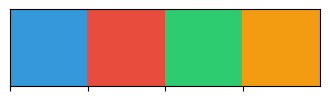

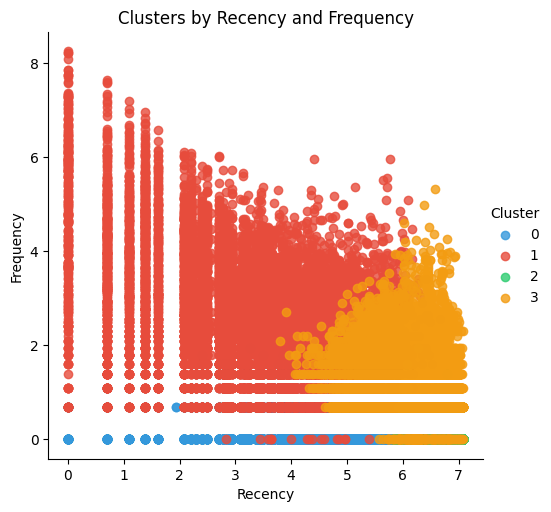

In [20]:
rfm_fig = rfm.copy()
rfm_fig['Frequency'] = np.log(rfm_fig['Frequency'])
rfm_fig['Recency'] = np.log(rfm_fig['Recency'])
rfm_fig['Monetary'] = np.cbrt(rfm_fig['Monetary'])
rfm_fig.head()
# Visualize the clusters using a lmplot
customPallete = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]
sns.set_palette(customPallete)
sns.palplot(customPallete)

data = pd.DataFrame(data=rfm_fig, columns=['CustomerID','Recency', 'Frequency', 'Monetary','Cluster'])

facet = sns.lmplot(data=data, x='Recency', y='Frequency', hue='Cluster', fit_reg=False)
plt.title('Clusters by Recency and Frequency')

Text(0.5, 1.0, 'Clusters by Frequency and Monetary')

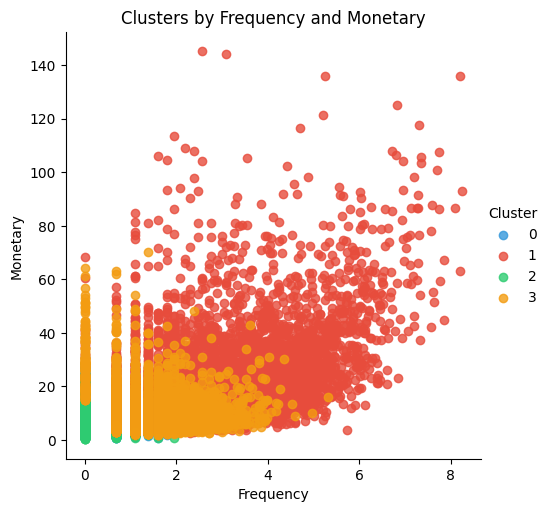

In [21]:
facet = sns.lmplot(data=data, x='Frequency',y='Monetary', hue='Cluster', fit_reg=False)
plt.title('Clusters by Frequency and Monetary')

Rscore and FMScore function take in the value to be scored *x*, the column name *p* and *d* the quantiles dictionar

In [22]:
numerical_features = rfm[['Recency', 'Frequency', 'Monetary']]
quantiles = numerical_features.quantile(q=[0.2,0.4,0.6,0.8])
quantiles = quantiles.to_dict()


'''
Recency Score.
Assigns Scores based on the quantile levels.
Customers who have purchased more recently get a higher score.
'''
def RScore(x,p,d):
    if x <= d[p][0.2]:
        return 5
    elif x <= d[p][0.4]:
        return 4
    elif x <= d[p][0.6]: 
        return 3
    elif x <= d[p][0.8]: 
        return 2
    else:
        return 1   
    
'''
Frequency and Monetary Score.
Assigns Scores based on the quantile levels but in reverse.
'''
def FMScore(x,p,d):
    if x <= d[p][0.2]:
        return 1
    elif x <= d[p][0.4]:
        return 2
    elif x <= d[p][0.6]: 
        return 3
    elif x <= d[p][0.8]: 
        return 4
    else:
        return 5
    
rfm['R'] = rfm['Recency'].apply(RScore, args=('Recency',quantiles,))
rfm['F'] = rfm['Frequency'].apply(FMScore, args=('Frequency',quantiles,))
rfm['M'] = rfm['Monetary'].apply(FMScore, args=('Monetary',quantiles,))
rfm['RFM_Score'] = rfm[['R','F','M']].sum(axis=1)

Assign buckets based on the RFM Scores

In [23]:
def assign_bucket(rfm_score):
    if rfm_score > 12:
        return 'Platinum'
    elif rfm_score <= 12 and rfm_score > 9:
        return 'Gold'
    elif rfm_score <= 9 and rfm_score > 6:
        return 'Silver'
    elif rfm_score <= 6 and rfm_score > 3:
        return 'Bronze'
    else:
        return 'Silicone'

buckets = ['Platinum', 'Gold', 'Silver', 'Bronze', 'Silicone']
rfm['Segments'] = rfm['RFM_Score'].apply(assign_bucket)
rfm.head()

,Recency,Frequency,Monetary,ProductCode,Cluster,R,F,M,RFM_Score,Segments
ProductCode,,,,,,,,,,
"16,X8Aew6833",82,2,39.30,"16,X8Aew6833",0,5,3,1,9,Silver
"SS,22Aew1908",16,2,138.66,"SS,22Aew1908",0,5,3,2,10,Gold
""" 27""""154DW7457""",618,3,37013.87,""" 27""""154DW7457""",3,2,4,5,11,Gold
""" 8"""" N80OU8459""",183,1,107.56,""" 8"""" N80OU8459""",0,4,1,2,7,Silver
""" 8"""" N80OU9161""",68,3,37.28,""" 8"""" N80OU9161""",0,5,4,1,10,Gold
